In [2]:
from pathlib import Path
import sys

def find_repo_root(start=None):
    p = Path(start or Path.cwd()).resolve()
    markers = ["README.md", ".git", "Models", "utils.py"]
    for d in [p] + list(p.parents):
        if any((d / m).exists() for m in markers):
            return d
    return p

ROOT = find_repo_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [3]:
from functools import partial
from utils import *
from Models.Generative_Closures.Generative_Models import *
from Models.Generative_Closures.Interpolant import *

import warnings
warnings.filterwarnings("ignore")

import matplotlib.pyplot as plt
plt.rc("text", usetex=True)
plt.rcParams["font.family"] = "Times New Roman"
plt.rcParams["text.latex.preamble"] = r"\usepackage{amsmath}"

In [4]:
# Check if CUDA is available
if torch.cuda.is_available():
    print("CUDA is available.")
    device = torch.device('cuda')
else:
    print("CUDA is not available.")
    device = torch.device('cpu')

# Load the data
DATA_PATH = ROOT / "Data" / "test_diffusion_nonlinear_B100.h5"
N = 10
with h5py.File(DATA_PATH, 'r') as file:
    test_nonlinear = torch.tensor(file['test_nonlinear_64'][:N], device=device)
    test_vorticity = torch.tensor(file['test_vorticity_64'][:N], device=device)

metrics = ErrorMetrics()

CUDA is available.


In [5]:
def sample_closure_field(
    method: str,
    model: torch.nn.Module,
    omega: torch.Tensor,
    num_ensembles: int = 1,
    sample_steps: int = 100,
    sigma_coef: float = 1.0,
    time_min: float = 1e-3,
    time_max: float = 1.0,
    time_schedule: str = 'uniform',   # 'uniform' or 'karras'
    return_starting_field: bool = False,
    device: str = 'cuda',
):
    """
    Unified closure sampler for 'diffusion', 'onesided', and 'twosided' methods.
    - 'DM'  : standard score-based SDE sampler
    - 'FM'   : flow matching sampler
    - 'SI_known' : stochastic interpolant sampler with known base dist
    - 'SI_gaussian' : stochastic interpolant sampler with gaussian base dist

    Returns:
        Tensor of shape (B, num_ensembles, H, W).  If return_starting_field=True,
    """
    B, H, W = omega.shape
    omega = omega.to(device)
    model = model.to(device)
    model.eval()

    # 1) Build the time grid ts = [time_max, ..., time_min]
    if time_schedule == 'uniform':
        ts = torch.linspace(time_max, time_min, sample_steps+1, device=device)
        ts_forward = torch.linspace(time_min, time_max, sample_steps+1, device=device)
    elif time_schedule == 'karras':
        ts = get_sigmas_karras(sample_steps, time_min, time_max, device=device)
        ts_forward = reversed(ts)
    else:
        raise ValueError(f"Unknown time_schedule: {time_schedule}")
    dt = ts[:-1] - ts[1:]  # step sizes for Euler integration
    dt_forward = ts_forward[1:] - ts_forward[:-1]

    # 2) Tile conditioning omega to match ensemble dimension
    omega_rep = omega.unsqueeze(1).repeat(1, num_ensembles, 1, 1).view(-1, H, W)

    if method == 'DM':
        marginal_prob_std_fn = partial(marginal_prob_std, sigma=sigma_coef, device_=device)
        diffusion_coeff_fn = partial(diffusion_coeff, sigma=sigma_coef, device_=device)
        # 3) Initialize x at t = ts[0] ~ N(0, [marginal std]^2)
        t0 = ts[0].repeat(B * num_ensembles)
        x = torch.randn_like(omega_rep) * marginal_prob_std_fn(t0)[:, None, None]
        x0 = x.clone()  # store initial noise if requested

        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = x.clone()


        with torch.no_grad():
            for i in range(sample_steps):
                t_i = ts[i].repeat(B * num_ensembles)
                step_size = dt[i]

                g = diffusion_coeff_fn(t_i)        # shape [B*num_ensembles]
                grad = model(t_i, x, omega_rep)    # score: [B*num_ensembles, H, W]

                # Euler–Maruyama update:
                mean = x + (g**2)[:, None, None] * grad * step_size
                if i < sample_steps - 1:
                    noise = torch.randn_like(x)
                    x = mean + math.sqrt(step_size) * g[:, None, None] * noise
                else:
                    x = mean # no extra noise on final step

                dist = torch.sqrt(torch.sum((x - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(x)

        x = x.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            x0 = x0.view(B, num_ensembles, H, W)
            return x0, x, total_distance
        else:
            return x

    elif method == 'SI_known':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = omega_rep.clone()
        X0 = Xt.clone()  # store if requested


        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()

        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                gdot_scalar = 1 - t
                gdot = gdot_scalar.repeat(B * num_ensembles)
                gdot = gdot.view([B * num_ensembles] + [1] * (Xt.ndim - 1))

                # 4.3) Euler–Maruyama backward step (no sign flip: dt>0, but X_{t-dt}=X_t - drift*dt + ...)
                if i < sample_steps - 1:
                    noise = torch.randn_like(Xt)
                    # Xt = Xt + drift * step_size
                    Xt = Xt + drift * step_size + gdot * math.sqrt(step_size) * noise
                else:
                    Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)

        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt


    elif method == 'SI_gaussian':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = torch.randn_like(omega_rep)
        X0 = Xt.clone()  # store if requested

        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()

        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                gdot_scalar = 1 - t
                gdot = gdot_scalar.repeat(B * num_ensembles)
                gdot = gdot.view([B * num_ensembles] + [1] * (Xt.ndim - 1))

                # 4.3) Euler–Maruyama backward step (no sign flip: dt>0, but X_{t-dt}=X_t - drift*dt + ...)
                if i < sample_steps - 1:
                    noise = torch.randn_like(Xt)
                    Xt = Xt + drift * step_size + gdot * math.sqrt(step_size) * noise
                else:
                    Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)

        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt

    elif method == 'FM':
        # 3) Initialize X_t at t=ts[0]=1 as x1 = omega_rep
        Xt = torch.randn_like(omega_rep)
        X0 = Xt.clone()  # store if requested
        total_distance = torch.zeros(B * num_ensembles, device=device)
        x_prev = Xt.clone()
        with torch.no_grad():
            for i in range(sample_steps):
                t = ts_forward[i]                                  # scalar in [0,1]
                step_size = dt_forward[i]                          # > 0
                t_batch = t.repeat(B * num_ensembles).to(device)
                drift = model(t_batch, Xt, omega_rep)      # [B*num_ensembles, H, W]
                Xt = Xt + drift * step_size

                dist = torch.sqrt(torch.sum((Xt - x_prev)**2, dim=(1,2)))
                total_distance += dist

                # prepare for next iteration
                x_prev.copy_(Xt)
        Xt = Xt.view(B, num_ensembles, H, W)
        total_distance = total_distance.view(B, num_ensembles)
        if return_starting_field:
            X0 = X0.view(B, num_ensembles, H, W)
            return X0, Xt, total_distance
        else:
            return Xt

    else:
        raise ValueError(f"Unknown sampling method: {method}")


Physical Space Models

In [6]:
set_seed(42)
num_ensembles = 100
modes = 6
width = 40

Random seed set as 42


Physical Space Score-based Diffusion Models

In [7]:
sigma = 30
marginal_prob_std_fn = partial(marginal_prob_std, sigma=sigma, device_=device)
pcdm = FNO2d_Diffusion(marginal_prob_std_fn, modes, modes, width, padding = 0, embed_dim = 512, length = 1).to(device)

pcdm_path = ROOT / "Trained_Models" / "DM" / "Physics_DM" / "P-CDM.pth"
pcdm.load_state_dict(torch.load(pcdm_path))

pcdm_starting_field, pcdm_samples, pcdm_sample_distances = sample_closure_field(
    method='DM',
    model=pcdm,
    omega=test_vorticity.float(),
    num_ensembles=num_ensembles,
    sample_steps=50,
    sigma_coef=sigma,
    time_min=0.001,
    time_max=1,
    time_schedule='karras',
    return_starting_field=True,
    device=device
)

pcdm_samples_mean = pcdm_samples.mean(dim=1)
pcdm_mse = metrics.mse(test_nonlinear, pcdm_samples_mean)
pcdm_fro = metrics.frobenius(test_nonlinear, pcdm_samples_mean)
samples_std = pcdm_samples[:].std(dim=1)

print(f"Physical MSE: {pcdm_mse:.3e}, Physical Frobenius: {pcdm_fro:.3e}")
print(f"Sample Standard Deviation: {samples_std.mean():.3e}")

Physical MSE: 4.288e-04, Physical Frobenius: 8.329e-02
Sample Standard Deviation: 1.944e-02


Physical Space Flow Matching

In [8]:
PFM = FNO2d_Orig(modes, modes, width, padding = 0, embed_dim = 256, length = 1).to(device)

model_name = ROOT / "Trained_Models" / "FM" / "Physics_FM" / "P-FM.pth"
PFM.load_state_dict(torch.load(model_name))

pfm_starting_field, pfm_samples, pfm_sample_distances = sample_closure_field(
    method='FM',
    model=PFM,
    omega=test_vorticity.float(),
    num_ensembles=num_ensembles,
    sample_steps=50,
    sigma_coef=1,
    time_min=0,
    time_max=1,
    time_schedule='uniform',
    return_starting_field=True,
    device=device
)

fm_samples_mean = pfm_samples.mean(dim=1)
pfm_mse = metrics.mse(test_nonlinear, fm_samples_mean)
pfm_fro = metrics.frobenius(test_nonlinear, fm_samples_mean)
samples_std = pfm_samples.std(dim=1)

print(f"Physical MSE: {pfm_mse:.3e}, Physical Frobenius: {pfm_fro:.3e}")
print(f"Sample Standard Deviation: {samples_std.mean():.3e}")

Physical MSE: 4.548e-04, Physical Frobenius: 8.556e-02
Sample Standard Deviation: 1.998e-02


 Stochastic Interpolant with SDE and Gaussian Base

In [ ]:
SISDE_Gaussian = FNO2d_Orig(modes, modes, width, padding = 0, embed_dim = 256, length = 1).to(device)

model_name = ROOT / "Trained_Models" / "SI" / "Physics_SI" / "P-SI_Gaussian.pth"
SISDE_Gaussian.load_state_dict(torch.load(model_name))

psigaussian_starting_field, psigaussian_samples, psigaussian_sample_distances = sample_closure_field(
    method='SI_gaussian',
    model=SISDE_Gaussian,
    omega=test_vorticity.float(),
    num_ensembles=num_ensembles,
    sample_steps=50,
    sigma_coef=1.0,
    time_min=0,
    time_max=1,
    time_schedule='uniform',
    return_starting_field=True,
    device=device
)

psigaussian_samples_mean = psigaussian_samples.mean(dim=1)
psigaussian_mse = metrics.mse(test_nonlinear, psigaussian_samples_mean)
psigaussian_fro = metrics.frobenius(test_nonlinear, psigaussian_samples_mean)
samples_std = psigaussian_samples.std(dim=1)

print(f"Physical MSE: {psigaussian_mse:.3e}, Physical Frobenius: {psigaussian_fro:.3e}")
print(f"Sample Standard Deviation: {samples_std.mean():.3e}")

Physical MSE: 4.575e-04, Physical Frobenius: 8.617e-02
Sample Standard Deviation: 2.046e-02


Stochastic Interpolant with SDE and Empirical Source

In [ ]:
SISDE_Empirical = FNO2d_Orig(modes, modes, width, padding = 0, embed_dim = 256, length = 1).to(device)

model_name = ROOT / "Trained_Models" / "SI" / "Physics_SI" / "P-SI_Empirical.pth"
SISDE_Empirical.load_state_dict(torch.load(model_name))

psiknown_starting_field, psiknown_samples, psiknown_sample_distances = sample_closure_field(
    method='SI_known',
    model=SISDE_Empirical,
    omega=test_vorticity.float(),
    num_ensembles=num_ensembles,
    sample_steps=50,
    sigma_coef=1.0,
    time_min=0,
    time_max=1,
    time_schedule='uniform',
    return_starting_field=True,
    device=device
)

psiknown_samples_mean = psiknown_samples.mean(dim=1)
psiknown_mse = metrics.mse(test_nonlinear, psiknown_samples_mean)
psiknown_fro = metrics.frobenius(test_nonlinear, psiknown_samples_mean)
samples_std = psiknown_samples[0].std(dim=0)

print(f"Physical MSE: {psiknown_mse:.3e}, Physical Frobenius: {psiknown_fro:.3e}")
print(f"Sample Standard Deviation: {samples_std.mean():.3e}")

Physical MSE: 4.497e-04, Physical Frobenius: 8.553e-02
Sample Standard Deviation: 2.057e-02


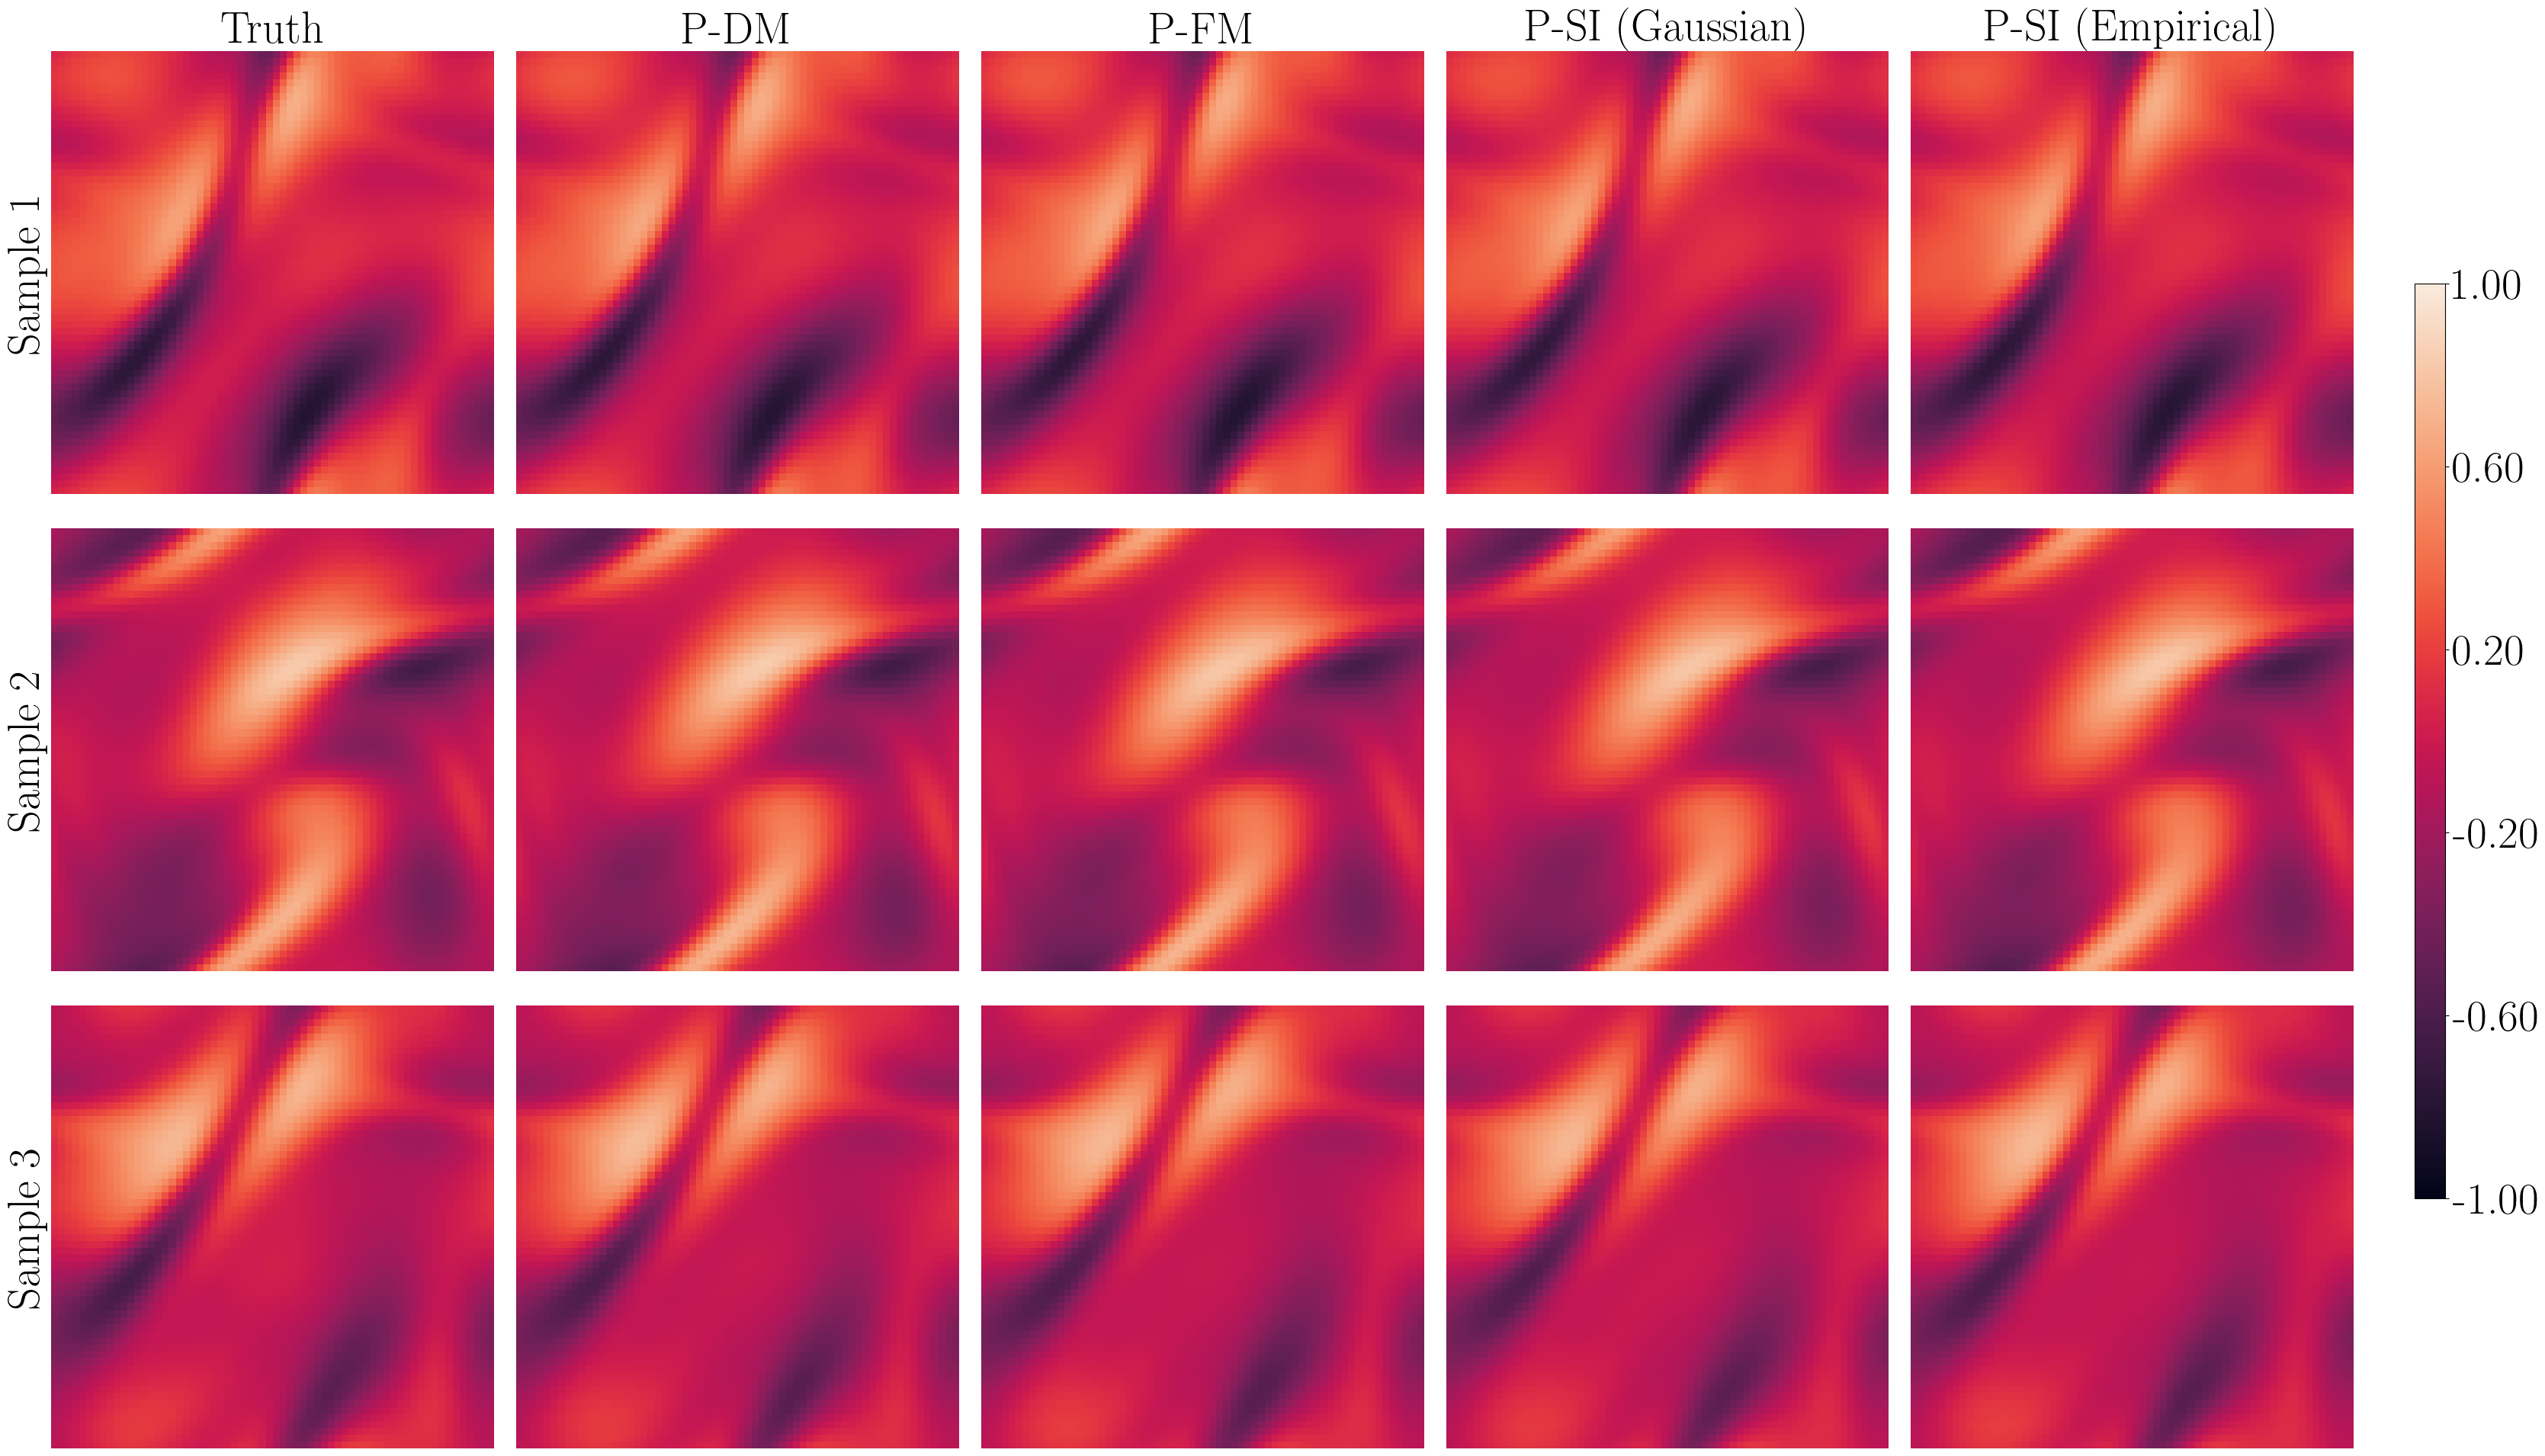

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def round_down_to_05(x):
    return np.floor(x * 2) / 2

def round_up_to_05(x):
    return np.ceil(x * 2) / 2

idx = [1, 5, 6]
cbar_shrink = 0.78 
model_names = ["P-DM", "P-FM", "P-SI (Gaussian)", "P-SI (Empirical)"]

samples = [
    pcdm_samples_mean[idx, ...].cpu().numpy(),
    fm_samples_mean[idx, ...].cpu().numpy(),
    psigaussian_samples_mean[idx, ...].cpu().numpy(),
    psiknown_samples_mean[idx, ...].cpu().numpy()
]
gt_field = test_nonlinear[idx, ...].cpu().numpy()


vmin_decoded, vmax_decoded = -0.8, 0.7
vmin_err, vmax_err = 0.0, 0.25
err_levels = np.linspace(vmin_err, vmax_err, 6)


n_rows = len(idx)                     # 4
n_cols = 1 + len(model_names)         # 5
fig, axs = plt.subplots(n_rows, n_cols, figsize=(8 * n_cols, 8 * n_rows))
fs = 42
plt.rcParams.update({'font.size': fs})

if n_rows == 1:
    axs = np.array([axs])

all_fields = [gt_field] + samples
global_min = min(f.min() for arr in all_fields for f in arr)
global_max = max(f.max() for arr in all_fields for f in arr)
vmin = round_down_to_05(global_min)
vmax = round_up_to_05(global_max)


for r in range(n_rows):
    fields_row = [gt_field[r]] + [s[r] for s in samples]
    for c, f in enumerate(fields_row):
        im = sns.heatmap(
            f, ax=axs[r, c], cmap='rocket',
            vmin=vmin, vmax=vmax, square=True,
            cbar=False 
        )

    axs[r, 0].set_ylabel(f"Sample {r+1}", fontsize=fs, rotation=90)
col_titles = ["Truth"] + model_names
for c, title in enumerate(col_titles):
    axs[0, c].set_title(title, fontsize=fs)

for ax in axs.flat:
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xticklabels([])
    ax.set_yticklabels([])
    ax.tick_params(axis='both', which='both', length=0)

fig.subplots_adjust(right=0.88, wspace=0.05, hspace=0.05)  
cbar_ax = fig.add_axes([0.90, 0.25, 0.01, 0.5])
norm = plt.Normalize(vmin=vmin, vmax=vmax)
sm = plt.cm.ScalarMappable(cmap='rocket', norm=norm)
fig.colorbar(sm, cax=cbar_ax, format='%.2f', ticks=np.linspace(vmin, vmax, 6))

# plt.subplots_adjust(right=0.9, hspace=0.3, wspace=0.5)
# plt.savefig("physics-model-samples.png", dpi=300, bbox_inches='tight')
plt.show()
